# Stim vs Pause Slopes: Per-Patient Time Trends

For each patient, compare two slopes side by side:
- **Left panel (Stim)**: slope fitted through BL + stim blocks only (odd blocks)
- **Right panel (Pause)**: slope fitted through BL + pause blocks only (even blocks)

Each line = one patient. Blue = negative slope, red = positive slope.
Thick black line = group average.

Two versions:
1. **Raw values**
2. **% change from baseline** (subjects without BL excluded)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, ttest_rel, wilcoxon
import warnings

warnings.filterwarnings('ignore')
sns.set(style='white', context='talk')
print('Setup done.')

Setup done.


## 1. Load & reshape data

In [2]:
RATE_PATH = r'final_firing_rates_wide.csv'
AMP_PATH  = r'final_amplitudes_wide.csv'


def load_and_melt(path, value_name):
    df = pd.read_csv(path)
    block_cols = [c for c in df.columns if c != 'Subject_ID']
    long = df.melt(id_vars='Subject_ID', value_vars=block_cols,
                   var_name='block_label', value_name=value_name)
    long = long.dropna(subset=[value_name]).copy()
    long['block_number'] = long['block_label'].apply(
        lambda x: 0 if x == 'BL' else int(x.split('_')[1]))

    def _type(label):
        if label == 'BL':
            return 'baseline'
        num = int(label.split('_')[1])
        return 'stim' if num % 2 == 1 else 'pause'

    long['block_type'] = long['block_label'].apply(_type)
    long['Subject_ID'] = long['Subject_ID'].astype(str)
    long = long.sort_values(['Subject_ID', 'block_number']).reset_index(drop=True)
    return long


df_rate = load_and_melt(RATE_PATH, 'firing_rate')
df_amp  = load_and_melt(AMP_PATH,  'amplitude')

# Subjects with baseline
has_bl_rate = set(df_rate[df_rate['block_type'] == 'baseline']['Subject_ID'].unique())
has_bl_amp  = set(df_amp[df_amp['block_type'] == 'baseline']['Subject_ID'].unique())

print(f'All subjects: {sorted(df_rate.Subject_ID.unique())}')
print(f'With BL: {sorted(has_bl_rate)}')
print(f'Without BL: {sorted(set(df_rate.Subject_ID.unique()) - has_bl_rate)}')

All subjects: ['485', '486', '487', '488', '497', '498', '499', '505', '5107', '515', '520', '545']
With BL: ['485', '486', '487', '488', '497', '498', '499', '505', '5107', '520']
Without BL: ['515', '545']


---
## 2. Core: side-by-side stim vs pause slopes

In [3]:
def compute_slopes(df, dv, condition, normalize_bl=False, exclude_no_bl=False):
    """
    Compute per-subject slope through BL + condition blocks.

    condition: 'stim' or 'pause'
    Returns dict {subject_id: (slope, intercept, xmin, xmax)}
    """
    # Keep BL + the target condition
    data = df[df['block_type'].isin(['baseline', condition])].copy()

    if exclude_no_bl:
        subjs_with_bl = set(data[data['block_type'] == 'baseline']['Subject_ID'].unique())
        data = data[data['Subject_ID'].isin(subjs_with_bl)].copy()

    if normalize_bl:
        bl_vals = (data[data['block_type'] == 'baseline']
                   .groupby('Subject_ID')[dv].mean().to_dict())
        data['_bl'] = data['Subject_ID'].map(bl_vals)
        # drop subjects with no BL mapping
        data = data.dropna(subset=['_bl'])
        data[dv] = ((data[dv] - data['_bl']) / data['_bl']) * 100
        data = data.drop(columns='_bl')

    results = {}
    for subj in sorted(data['Subject_ID'].unique()):
        sub = data[data['Subject_ID'] == subj].sort_values('block_number')
        x = sub['block_number'].values.astype(float)
        y = sub[dv].values.astype(float)
        mask = np.isfinite(y)
        x, y = x[mask], y[mask]
        if len(x) < 2:
            continue
        res = linregress(x, y)
        results[subj] = (res.slope, res.intercept, x.min(), x.max())

    return results


def plot_stim_vs_pause(df, dv, feature_label, normalize_bl=False):
    """
    Side-by-side: left = stim slopes, right = pause slopes.
    """
    exclude = normalize_bl  # if normalizing to BL, must have BL

    stim_slopes  = compute_slopes(df, dv, 'stim',  normalize_bl, exclude)
    pause_slopes = compute_slopes(df, dv, 'pause', normalize_bl, exclude)

    # Use only subjects present in BOTH
    common = sorted(set(stim_slopes.keys()) & set(pause_slopes.keys()))
    if not common:
        print('No common subjects!')
        return

    norm_label = '% Change from BL' if normalize_bl else 'Raw'
    ylabel = f'% Change from Baseline' if normalize_bl else feature_label

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    paired_stim_slopes = []
    paired_pause_slopes = []

    for panel_idx, (condition, slopes_dict, panel_title) in enumerate([
        ('stim',  stim_slopes,  'BL + Stim Blocks'),
        ('pause', pause_slopes, 'BL + Pause Blocks'),
    ]):
        ax = axes[panel_idx]

        # Collect slopes for common subjects only
        panel_slopes = []
        panel_intercepts = []
        all_xmin, all_xmax = 999, 0

        for subj in common:
            s, b, xmin, xmax = slopes_dict[subj]
            panel_slopes.append(s)
            panel_intercepts.append(b)
            all_xmin = min(all_xmin, xmin)
            all_xmax = max(all_xmax, xmax)

            color = '#d9534f' if s > 0 else '#4a90d9'
            x_line = np.array([xmin, xmax])
            ax.plot(x_line, b + s * x_line,
                    color=color, alpha=0.45, linewidth=1.5)

        # Store for paired test
        if condition == 'stim':
            paired_stim_slopes = panel_slopes
        else:
            paired_pause_slopes = panel_slopes

        # Average line
        avg_s = np.mean(panel_slopes)
        avg_b = np.mean(panel_intercepts)
        x_avg = np.array([all_xmin, all_xmax])
        ax.plot(x_avg, avg_b + avg_s * x_avg,
                color='black', linewidth=3, linestyle='-',
                label=f'Avg slope = {avg_s:.4f}', zorder=10)

        n_neg = sum(1 for s in panel_slopes if s <= 0)
        n_pos = sum(1 for s in panel_slopes if s > 0)

        ax.set_title(f'{panel_title}\n'
                     f'{n_neg} neg (blue), {n_pos} pos (red)\n'
                     f'Avg slope = {avg_s:.4f}',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Block Number', fontsize=12)
        if panel_idx == 0:
            ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax.legend(fontsize=10, loc='best')

        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_linewidth(1.5)

    fig.suptitle(f'{feature_label} – Stim vs Pause Slopes ({norm_label}, N={len(common)})',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ── Stats: paired comparison of slopes ──
    print(f'\n=== {feature_label} ({norm_label}) – Slope Comparison ===')
    print(f'  N subjects (paired): {len(common)}')
    print(f'  Avg stim  slope: {np.mean(paired_stim_slopes):+.4f}')
    print(f'  Avg pause slope: {np.mean(paired_pause_slopes):+.4f}')
    print(f'  Difference (stim - pause): {np.mean(paired_stim_slopes) - np.mean(paired_pause_slopes):+.4f}')

    if len(common) >= 3:
        t_stat, t_p = ttest_rel(paired_stim_slopes, paired_pause_slopes)
        w_stat, w_p = wilcoxon(paired_stim_slopes, paired_pause_slopes)
        print(f'  Paired t-test: t = {t_stat:.3f}, p = {t_p:.4g}')
        print(f'  Wilcoxon:      W = {w_stat:.1f}, p = {w_p:.4g}')

    print(f'\n  Per-subject slopes:')
    print(f'  {"Subject":<10} {"Stim":>10} {"Pause":>10} {"Diff":>10}')
    print(f'  {"-"*40}')
    for i, subj in enumerate(common):
        ss = paired_stim_slopes[i]
        ps = paired_pause_slopes[i]
        print(f'  {subj:<10} {ss:+10.4f} {ps:+10.4f} {ss-ps:+10.4f}')
    print()

---
## 3. Firing Rate

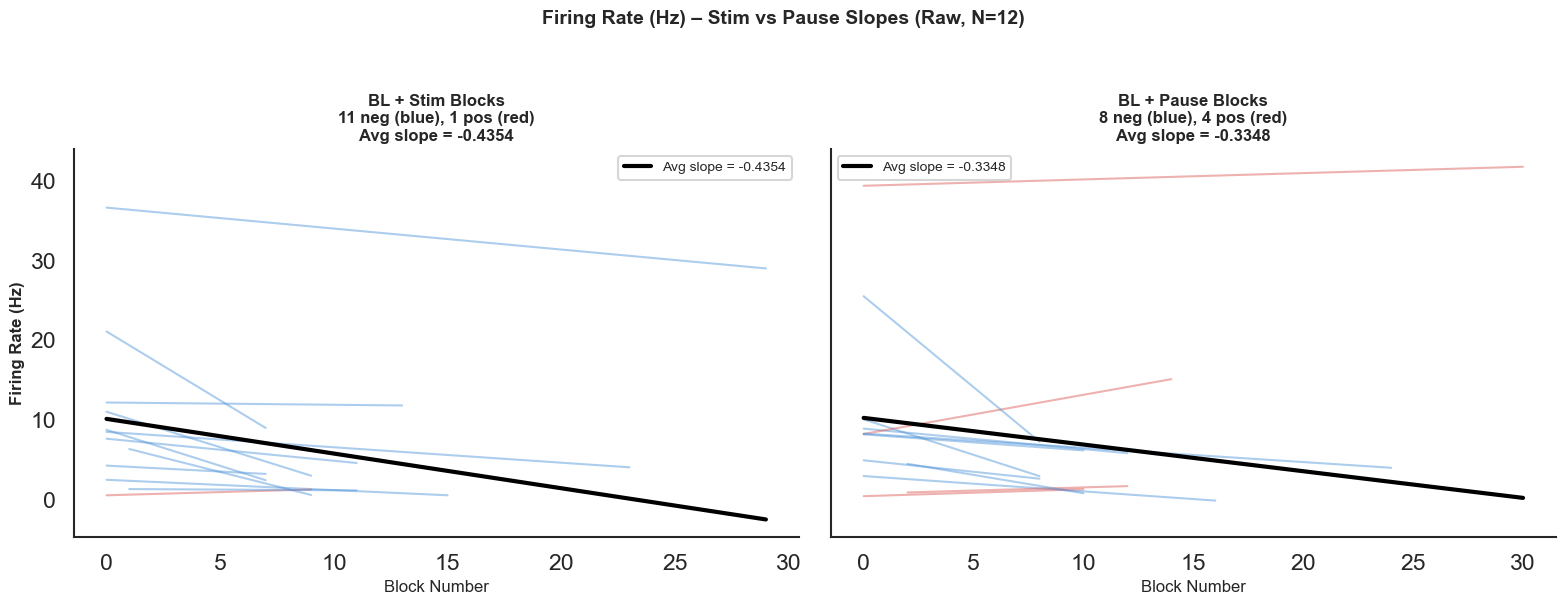


=== Firing Rate (Hz) (Raw) – Slope Comparison ===
  N subjects (paired): 12
  Avg stim  slope: -0.4354
  Avg pause slope: -0.3348
  Difference (stim - pause): -0.1006
  Paired t-test: t = -1.077, p = 0.3045
  Wilcoxon:      W = 23.0, p = 0.2334

  Per-subject slopes:
  Subject          Stim      Pause       Diff
  ----------------------------------------
  485           -0.9039    -0.8916    -0.0124
  486           -0.1487    -0.2884    +0.1396
  487           -0.2773    -0.2568    -0.0205
  488           -0.0285    +0.4921    -0.5206
  497           -0.2633    +0.0795    -0.3428
  498           -0.1935    -0.1789    -0.0146
  499           -0.1297    -0.1926    +0.0629
  505           -0.8927    -0.2021    -0.6906
  5107          +0.0809    +0.0874    -0.0065
  515           -0.0161    +0.0796    -0.0957
  520           -1.7307    -2.2842    +0.5535
  545           -0.7217    -0.4624    -0.2593


In [4]:
# Raw values
plot_stim_vs_pause(df_rate, 'firing_rate', 'Firing Rate (Hz)',
                   normalize_bl=False)

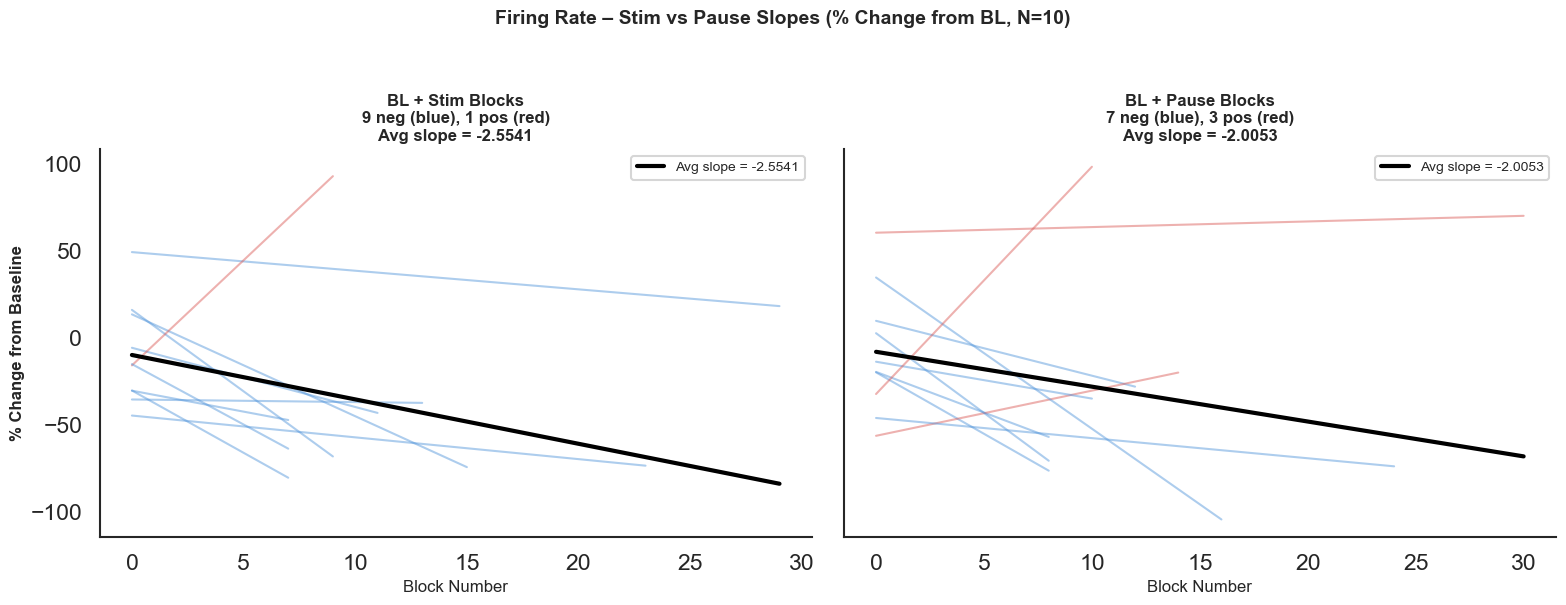


=== Firing Rate (% Change from BL) – Slope Comparison ===
  N subjects (paired): 10
  Avg stim  slope: -2.5541
  Avg pause slope: -2.0053
  Difference (stim - pause): -0.5488
  Paired t-test: t = -0.589, p = 0.5705
  Wilcoxon:      W = 22.0, p = 0.625

  Per-subject slopes:
  Subject          Stim      Pause       Diff
  ----------------------------------------
  485           -7.1677    -7.0697    -0.0980
  486           -2.4113    -4.6754    +2.2641
  487           -3.4060    -3.1542    -0.2518
  488           -0.1503    +2.5983    -2.7486
  497           -1.0713    +0.3236    -1.3948
  498           -1.2536    -1.1588    -0.0948
  499           -5.8587    -8.6983    +2.8396
  505           -9.3678    -2.1204    -7.2474
  5107         +12.0937   +13.0717    -0.9780
  520           -6.9477    -9.1698    +2.2221


In [5]:
# Baseline-normalized %
plot_stim_vs_pause(df_rate, 'firing_rate', 'Firing Rate',
                   normalize_bl=True)

---
## 4. Amplitude

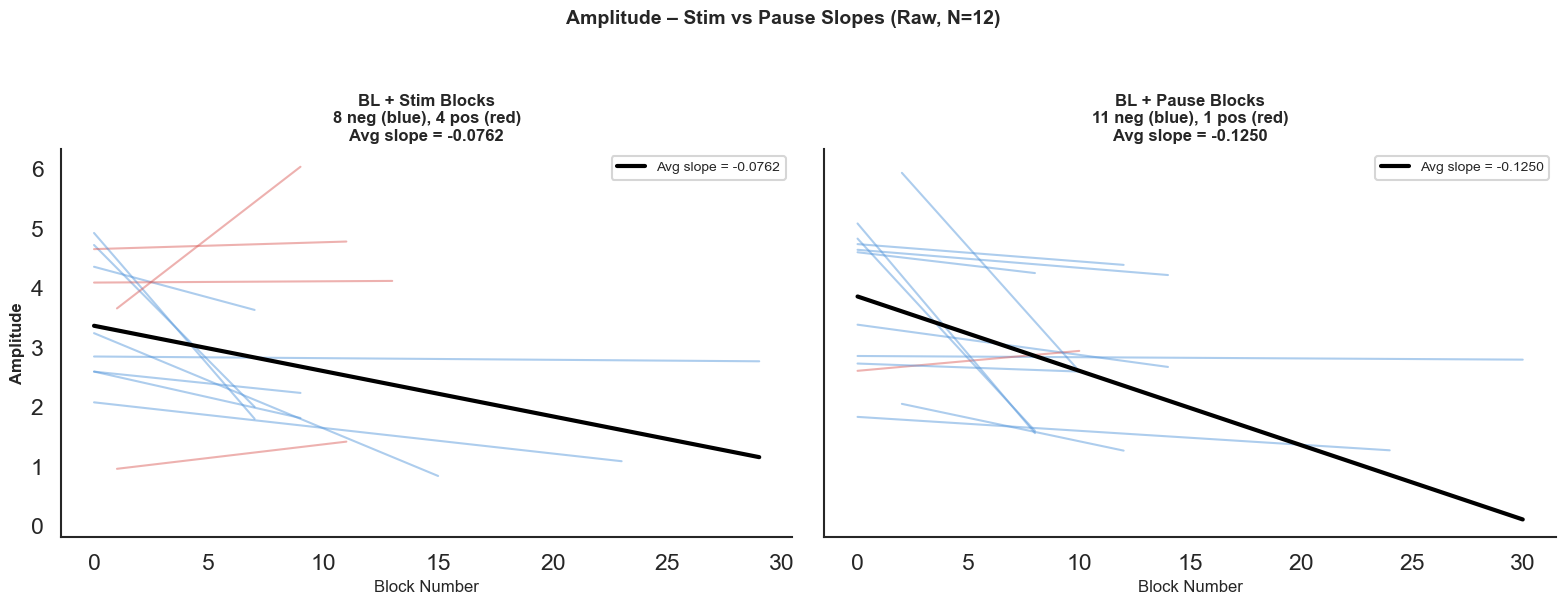


=== Amplitude (Raw) – Slope Comparison ===
  N subjects (paired): 12
  Avg stim  slope: -0.0762
  Avg pause slope: -0.1250
  Difference (stim - pause): +0.0488
  Paired t-test: t = 0.772, p = 0.4564
  Wilcoxon:      W = 37.0, p = 0.9097

  Per-subject slopes:
  Subject          Stim      Pause       Diff
  ----------------------------------------
  485           -0.3888    -0.4039    +0.0151
  486           -0.1037    -0.0437    -0.0599
  487           +0.0116    -0.0291    +0.0407
  488           +0.0021    -0.0303    +0.0325
  497           -0.0028    -0.0021    -0.0007
  498           -0.0430    -0.0234    -0.0196
  499           -0.1601    -0.0508    -0.1093
  505           -0.0398    +0.0335    -0.0733
  5107          -0.0868    -0.0135    -0.0732
  515           +0.0457    -0.0786    +0.1243
  520           -0.4463    -0.4407    -0.0056
  545           +0.2977    -0.4169    +0.7146


In [6]:
# Raw values
plot_stim_vs_pause(df_amp, 'amplitude', 'Amplitude',
                   normalize_bl=False)

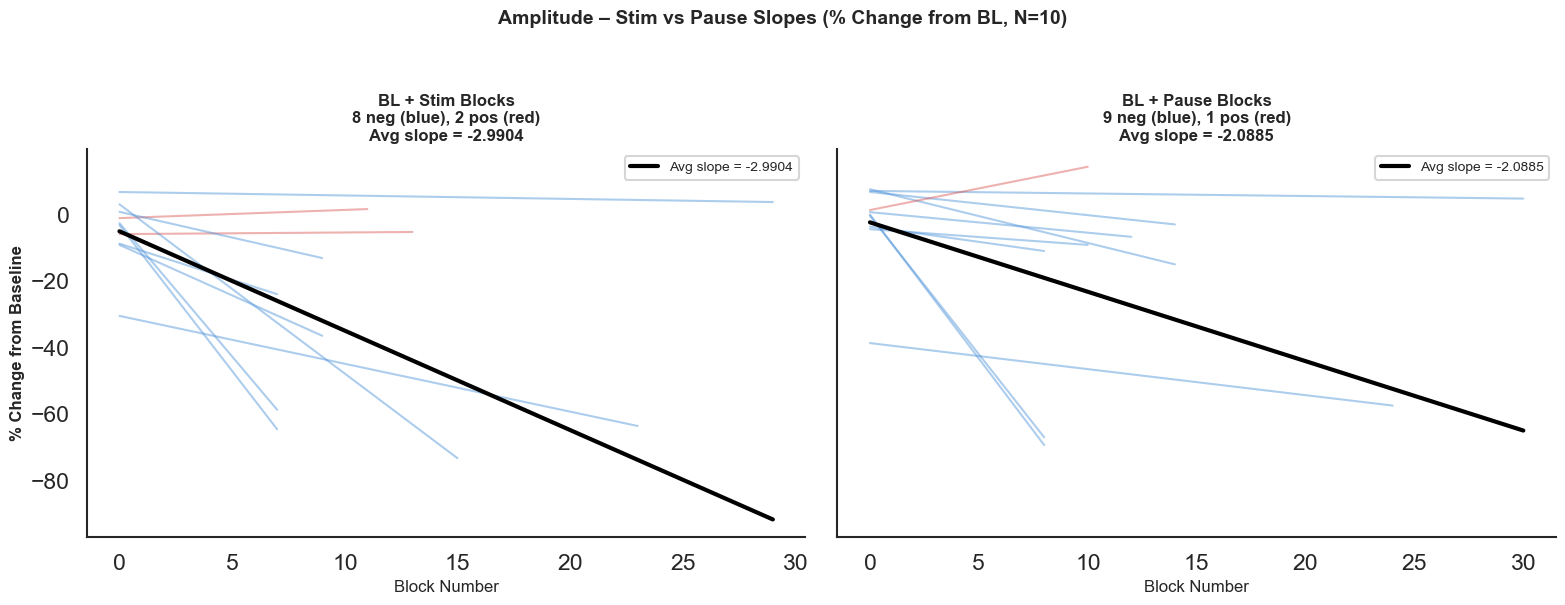


=== Amplitude (% Change from BL) – Slope Comparison ===
  N subjects (paired): 10
  Avg stim  slope: -2.9904
  Avg pause slope: -2.0885
  Difference (stim - pause): -0.9019
  Paired t-test: t = -1.821, p = 0.102
  Wilcoxon:      W = 14.0, p = 0.1934

  Per-subject slopes:
  Subject          Stim      Pause       Diff
  ----------------------------------------
  485           -8.0253    -8.3372    +0.3119
  486           -2.1723    -0.9166    -1.2557
  487           +0.2465    -0.6188    +0.8653
  488           +0.0493    -0.6977    +0.7469
  497           -0.1042    -0.0769    -0.0273
  498           -1.4407    -0.7835    -0.6572
  499           -5.0933    -1.6148    -3.4784
  505           -1.5456    +1.3024    -2.8480
  5107          -3.0393    -0.4736    -2.5657
  520           -8.7789    -8.6682    -0.1106


In [7]:
# Baseline-normalized %
plot_stim_vs_pause(df_amp, 'amplitude', 'Amplitude',
                   normalize_bl=True)